In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

patients = pd.read_csv(r'C:\Users\malaa\Downloads\patients_clean.csv')

knn_features = ['Age', 'Monthly Income JD', 'Need Score 0 to 1',
                'Urgency Score', 'CancerStageNum',
                'Total Dependents', 'Days on Waitlist']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(patients[knn_features])
print("Data loaded and scaled successfully")
print("Shape:", X_scaled.shape)

Data loaded and scaled successfully
Shape: (111, 7)


In [2]:
knn_model = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn_model.fit(X_scaled)
print("KNN model trained on", X_scaled.shape[0], "patients")
print("Features used:", knn_features)

KNN model trained on 111 patients
Features used: ['Age', 'Monthly Income JD', 'Need Score 0 to 1', 'Urgency Score', 'CancerStageNum', 'Total Dependents', 'Days on Waitlist']


In [3]:
def find_similar_patients(age, income, need_score, urgency,
                           stage_num, dependents, wait_days, k=4):
    query = np.array([[age, income, need_score, urgency,
                       stage_num, dependents, wait_days]])
    query_scaled = scaler.transform(query)
    distances, indices = knn_model.kneighbors(query_scaled,
                                               n_neighbors=k+1)
    results = patients.iloc[indices[0][1:]].copy()
    results['Similarity %'] = (
        (1 - distances[0][1:]) * 100
    ).round(1)
    display_cols = ['Patient ID', 'Cancer Type', 'Cancer Stage',
                    'Monthly Income JD', 'Need Score 0 to 1',
                    'Recommended Programs', 'Similarity %']
    return results[display_cols]

print("Function ready!")

Function ready!


In [4]:
# Test case: 45-year-old female, Stage III Breast Cancer
# 200 JD income, 3 dependents, 30 days waiting
result = find_similar_patients(
    age=45, income=200, need_score=0.75, urgency=0.45,
    stage_num=3, dependents=3, wait_days=30
)
print("=== 4 Most Similar Patients ===")
print(result.to_string(index=False))

=== 4 Most Similar Patients ===
Patient ID       Cancer Type Cancer Stage  Monthly Income JD  Need Score 0 to 1                                                                                                                                          Recommended Programs  Similarity %
      P231     Breast Cancer     Stage IV                100               0.68                                                        Goodwill Fund | Hotel Accommodation | CCI Insurance | Psychosocial Support | Medical Equipment Program          63.9
      P001     Breast Cancer    Stage III                200               0.73 Goodwill Fund | Zakat Fund | Transportation Allowance | Hotel Accommodation | CCI Insurance | Psychosocial Support | Medical Equipment Program | Meal Coupons          61.7
      P229 Colorectal Cancer    Stage III                200               0.67                                                  Goodwill Fund | Zakat Fund | CCI Insurance | Psychosocial Support | Medical Equipme

C:\Users\malaa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [5]:
def precision_at_4(query_idx, k=4):
    query_stage = patients.iloc[query_idx]['CancerStageNum']
    query_vec = X_scaled[query_idx].reshape(1, -1)
    distances, indices = knn_model.kneighbors(query_vec,
                                               n_neighbors=k+1)
    retrieved = patients.iloc[indices[0][1:]]
    relevant  = retrieved[
        abs(retrieved['CancerStageNum'] - query_stage) <= 1
    ]
    return len(relevant) / k

scores = [precision_at_4(i) for i in range(50)]
mean_p4 = np.mean(scores)
print(f"Mean Precision@4 : {mean_p4:.2f}")
print(f"Target           : >= 0.75")
print(f"Status           : {'PASS ✓' if mean_p4 >= 0.75 else 'NEEDS IMPROVEMENT'}")

Mean Precision@4 : 1.00
Target           : >= 0.75
Status           : PASS ✓


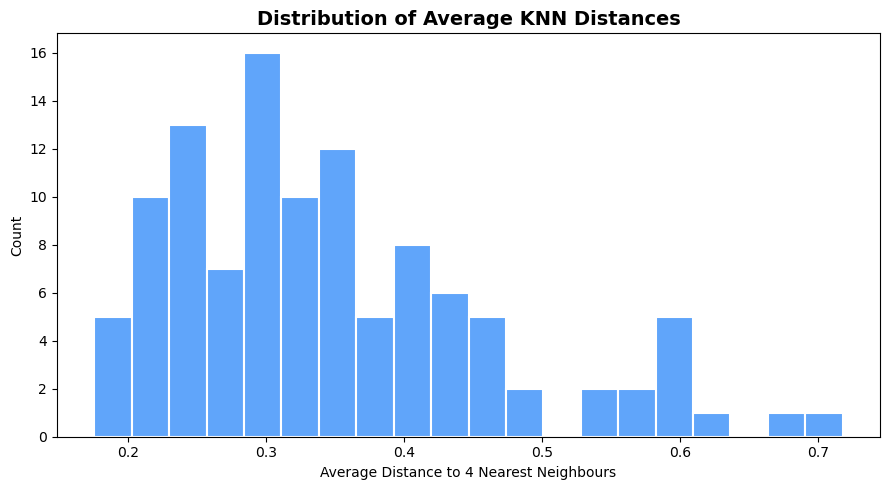

In [6]:
import matplotlib.pyplot as plt

sample_distances = []
for i in range(len(patients)):
    q = X_scaled[i].reshape(1, -1)
    d, _ = knn_model.kneighbors(q, n_neighbors=5)
    sample_distances.append(d[0][1:].mean())

plt.figure(figsize=(9, 5))
plt.hist(sample_distances, bins=20, color='#60A5FA',
         edgecolor='white', linewidth=1.5)
plt.title('Distribution of Average KNN Distances',
          fontsize=14, fontweight='bold')
plt.xlabel('Average Distance to 4 Nearest Neighbours')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\knn_distances.png',
            dpi=150, bbox_inches='tight')
plt.show()